# Sentiment Analysis - Study 2a

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import json
import re
from transformers import pipeline
from tqdm import tqdm
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

/opt/homebrew/Caskroom/miniforge/base/envs/tft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tqdm.pandas()

## Reading & cleaning the LLM responses

In [3]:
df = pd.read_csv('./data/ageRisk_complete.csv', index_col=0)

## Feature engineering

In [ ]:
def get_oneshot_classes(df, classes, col, prefix):
    for label in classes:
        df[f'{prefix}-{label}'] = df[col].apply(lambda x: x['scores'][x['labels'].index(label)])
    return df

### Presence of a disclaimer

In [ ]:
zero_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
candidates_disclaimer = ['disclaimer', 'no disclaimer']

df_disclaimer = df.copy()
df_disclaimer['disclaimer_raw'] = df_disclaimer['raw'].progress_apply(lambda res: zero_classifier(res, candidates_disclaimer))

In [ ]:
df_disclaimer = get_oneshot_classes(df_disclaimer, candidates_disclaimer, 'disclaimer_raw', 'disclaim')
df = df_disclaimer

### Presence of explanations

In [ ]:
candidates_explanations = ['explanations', 'no explanations']

df_explanations = df.copy()
df_explanations['explanations_raw'] = df_explanations['raw'].progress_apply(lambda res: zero_classifier(res, candidates_explanations))

In [ ]:
df_explanations = get_oneshot_classes(df_explanations, candidates_explanations, 'explanations_raw', 'explain')
df = df_explanations

### Assertiveness

In [ ]:
candidates_assertive = ['assertive', 'non-assertive']

df_assertive = df.copy()
df_assertive['assertiveness_raw'] = df_assertive['raw'].progress_apply(lambda res: zero_classifier(res, candidates_assertive))

In [ ]:
df_assertive = get_oneshot_classes(df_assertive, candidates_assertive, 'assertiveness_raw', 'assertive')
df = df_assertive

In [ ]:
df.to_csv('./data/sentiment_features.csv')

## Analysis

In [20]:
df = pd.read_csv('./data/sentiment_features.csv', index_col=0)
df.columns = df.columns.str.replace('-', '_').str.replace(' ', '_')
df['cond'] = df['cond'].replace({'control': 'Control prompt','engineered': 'Debiased prompt'})
df['risk_taking'] = df['risk_taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})

In [21]:
label_dict = {'ai':'GenAI', 'age':'Age', 'risk_taking':'Risk Tendency'}
rename_dict = {
    'disclaim_disclaimer' : 'Disclaimer',
    'disclaim_no_disclaimer':'No Disclaimer',
    'assertive_assertive':'Assertiveness',
    'assertive_non_assertive':'Non-Assertiveness',
    'explain_explanations':'Rationality',
    'explain_no_explanations':'Non-Rationality',  
}   

def show_colmeans(df, starter):
    for column_name in df.columns:
        if column_name.startswith(starter):
            print(f'mean for column {rename_dict[column_name]}: {round(df[column_name].mean(), 4)} with length: {df[column_name].size}')

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
def show_errplot(raw, column, column_label, group1, group2=None):
    if group1 == 'risk_taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
        
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    
    grouped = raw.groupby(groups, observed=False)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)
    
    plt.clf()
    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
        
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 4), zorder=2, color=colors)
    ax.set_ylabel(rename_dict[column_label])
    x_label = 'Condition' if group1 == 'cond' else label_dict.get(group1, group1)
    ax.set_xlabel(x_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.grid(True, zorder=1)
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2)
        legend.get_title().set_text(group2)

    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/sentiment/{group1}{group2_label}-{column_label}.png', bbox_inches='tight')
    
def show_model_details(df, starter, group1, group2=None):
    for column_name in df.columns:
        if column_name.startswith(starter):            
            show_errplot(df, column_name, column_name, group1, group2)
            plt.show()

### Disclaimer

In [22]:
show_colmeans(df, 'disclaim_')

mean for column Disclaimer: 0.9521 with length: 180
mean for column No Disclaimer: 0.0479 with length: 180


            sum_sq     df         F    PR(>F)
label     0.009029    1.0  6.187582  0.013785
Residual  0.259736  178.0       NaN       NaN
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Control prompt Debiased prompt  -0.0142 0.0138 -0.0254 -0.0029   True
---------------------------------------------------------------------
means:
cond
Control prompt     0.9592
Debiased prompt    0.9451
Name: disclaim_disclaimer, dtype: float64
stds:
cond
Control prompt     0.0316
Debiased prompt    0.0438
Name: disclaim_disclaimer, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: disclaim_disclaimer, dtype: int64


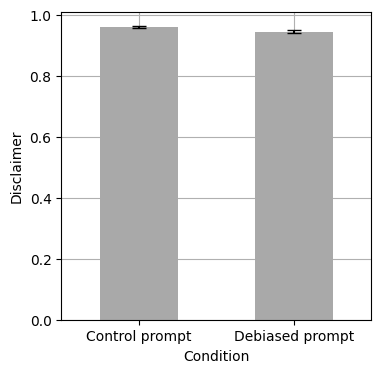

            sum_sq     df         F    PR(>F)
label     0.009029    1.0  6.187583  0.013785
Residual  0.259736  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1          group2     meandiff p-adj  lower  upper  reject
-------------------------------------------------------------------
Control prompt Debiased prompt   0.0142 0.0138 0.0029 0.0254   True
-------------------------------------------------------------------
means:
cond
Control prompt     0.0408
Debiased prompt    0.0549
Name: disclaim_no_disclaimer, dtype: float64
stds:
cond
Control prompt     0.0316
Debiased prompt    0.0438
Name: disclaim_no_disclaimer, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: disclaim_no_disclaimer, dtype: int64


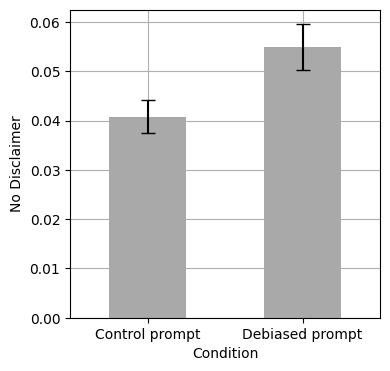

In [23]:
show_model_details(df, 'disclaim_', 'cond')

            sum_sq     df         F   PR(>F)
label     0.003367    1.0  2.258434  0.13466
Residual  0.265397  178.0       NaN      NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0042 0.8212 -0.0209 0.0125  False
    15     50  -0.0105 0.2983 -0.0272 0.0062  False
    30     50  -0.0063 0.6464  -0.023 0.0104  False
---------------------------------------------------
means:
age
15    0.9571
30    0.9528
50    0.9465
Name: disclaim_disclaimer, dtype: float64
stds:
age
15    0.0299
30    0.0368
50    0.0475
Name: disclaim_disclaimer, dtype: float64
age
15    60
30    60
50    60
Name: disclaim_disclaimer, dtype: int64


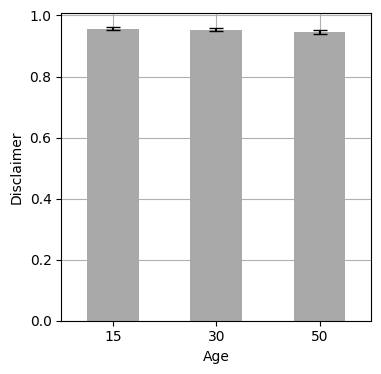

            sum_sq     df         F    PR(>F)
label     0.003367    1.0  2.258433  0.134661
Residual  0.265397  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0042 0.8212 -0.0125 0.0209  False
    15     50   0.0105 0.2983 -0.0062 0.0272  False
    30     50   0.0063 0.6464 -0.0104  0.023  False
---------------------------------------------------
means:
age
15    0.0429
30    0.0472
50    0.0535
Name: disclaim_no_disclaimer, dtype: float64
stds:
age
15    0.0299
30    0.0368
50    0.0475
Name: disclaim_no_disclaimer, dtype: float64
age
15    60
30    60
50    60
Name: disclaim_no_disclaimer, dtype: int64


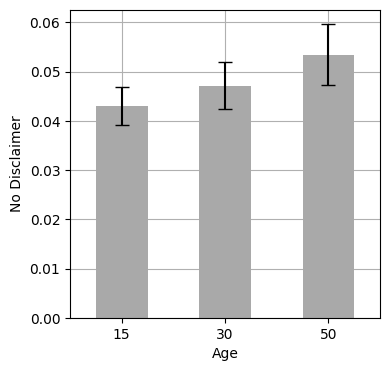

In [24]:
show_model_details(df, 'disclaim_', 'age')

            sum_sq     df         F    PR(>F)
label     0.018756    2.0  6.639456  0.001658
Residual  0.250009  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -0.0245 0.0013 -0.0407 -0.0083   True
  high medium  -0.0078 0.4905  -0.024  0.0084  False
   low medium   0.0167 0.0427  0.0004  0.0329   True
----------------------------------------------------
means:
risk_taking
low       0.9384
medium    0.9551
high      0.9629
Name: disclaim_disclaimer, dtype: float64
stds:
risk_taking
low       0.0478
medium    0.0340
high      0.0282
Name: disclaim_disclaimer, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: disclaim_disclaimer, dtype: int64


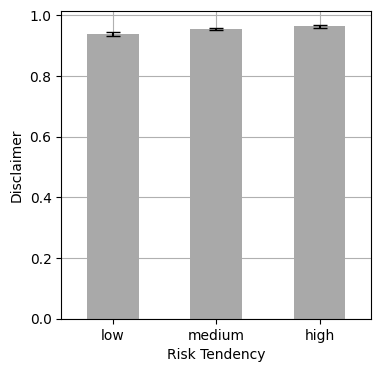

            sum_sq     df         F    PR(>F)
label     0.018756    2.0  6.639455  0.001658
Residual  0.250009  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low   0.0245 0.0013  0.0083  0.0407   True
  high medium   0.0078 0.4905 -0.0084   0.024  False
   low medium  -0.0167 0.0427 -0.0329 -0.0004   True
----------------------------------------------------
means:
risk_taking
low       0.0616
medium    0.0449
high      0.0371
Name: disclaim_no_disclaimer, dtype: float64
stds:
risk_taking
low       0.0478
medium    0.0340
high      0.0282
Name: disclaim_no_disclaimer, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: disclaim_no_disclaimer, dtype: int64


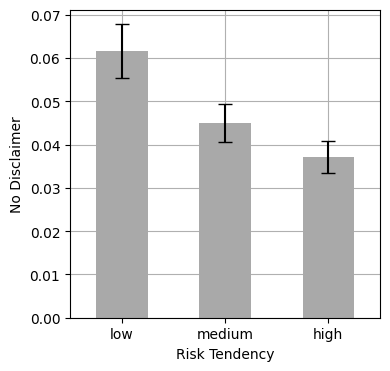

In [25]:
show_model_details(df, 'disclaim_', 'risk_taking')

            sum_sq     df         F    PR(>F)
label     0.028675    5.0  4.156253  0.001364
Residual  0.240090  174.0       NaN       NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -0.0204 0.2781  -0.048  0.0072  False
  (Control prompt, high)  (Control prompt, medium)  -0.0089 0.9383 -0.0366  0.0187  False
  (Control prompt, high)   (Debiased prompt, high)  -0.0122 0.8011 -0.0398  0.0155  False
  (Control prompt, high)    (Debiased prompt, low)  -0.0407 0.0005 -0.0684 -0.0131   True
  (Control prompt, high) (Debiased prompt, medium)  -0.0189 0.3628 -0.0466  0.0087  False
   (Control prompt, low)  (Control prompt, medium)   0.0115 0.8375 -0.0162  0.0391  False
   (Control prompt, low)   (Debiased prompt, high)  

<Figure size 640x480 with 0 Axes>

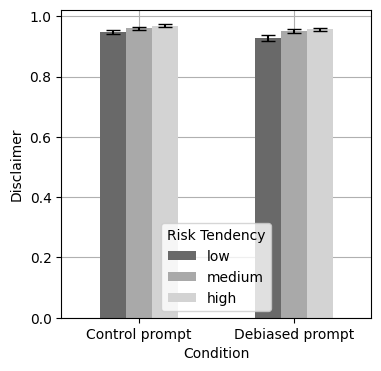

            sum_sq     df         F    PR(>F)
label     0.028675    5.0  4.156253  0.001364
Residual  0.240090  174.0       NaN       NaN
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower  upper  reject
----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)   0.0204 0.2781 -0.0072  0.048  False
  (Control prompt, high)  (Control prompt, medium)   0.0089 0.9383 -0.0187 0.0366  False
  (Control prompt, high)   (Debiased prompt, high)   0.0122 0.8011 -0.0155 0.0398  False
  (Control prompt, high)    (Debiased prompt, low)   0.0407 0.0005  0.0131 0.0684   True
  (Control prompt, high) (Debiased prompt, medium)   0.0189 0.3628 -0.0087 0.0466  False
   (Control prompt, low)  (Control prompt, medium)  -0.0115 0.8375 -0.0391 0.0162  False
   (Control prompt, low)   (Debiased prompt, high)  -0.0082 0

<Figure size 640x480 with 0 Axes>

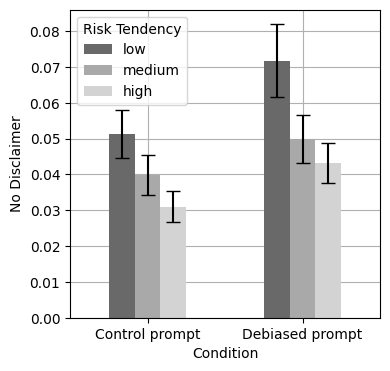

In [26]:
show_model_details(df, 'disclaim_', 'cond', 'risk_taking')

### Explanations

In [27]:
show_colmeans(df, 'explain_')

mean for column Rationality: 0.956 with length: 180
mean for column Non-Rationality: 0.044 with length: 180


            sum_sq     df         F    PR(>F)
label     0.001940    1.0  3.444537  0.065114
Residual  0.100234  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -0.0066 0.0651 -0.0135 0.0004  False
--------------------------------------------------------------------
means:
cond
Control prompt     0.9592
Debiased prompt    0.9527
Name: explain_explanations, dtype: float64
stds:
cond
Control prompt     0.0209
Debiased prompt    0.0262
Name: explain_explanations, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: explain_explanations, dtype: int64


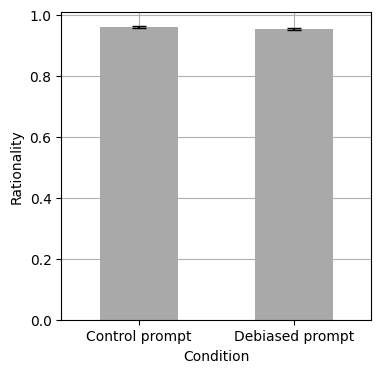

            sum_sq     df         F    PR(>F)
label     0.001940    1.0  3.444541  0.065114
Residual  0.100234  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt   0.0066 0.0651 -0.0004 0.0135  False
--------------------------------------------------------------------
means:
cond
Control prompt     0.0408
Debiased prompt    0.0473
Name: explain_no_explanations, dtype: float64
stds:
cond
Control prompt     0.0209
Debiased prompt    0.0262
Name: explain_no_explanations, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: explain_no_explanations, dtype: int64


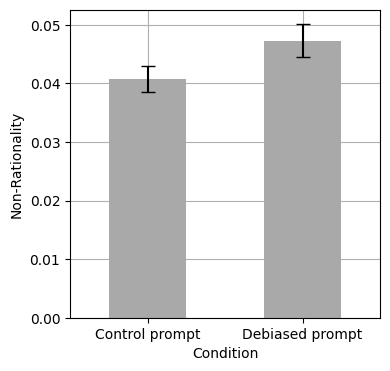

In [28]:
show_model_details(df, 'explain_', 'cond')

            sum_sq     df         F    PR(>F)
label     0.000287    1.0  0.500776  0.480085
Residual  0.101887  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0002 0.9983 -0.0106 0.0101  False
    15     50   0.0029 0.7805 -0.0074 0.0133  False
    30     50   0.0032 0.7484 -0.0072 0.0135  False
---------------------------------------------------
means:
age
15    0.9551
30    0.9548
50    0.9580
Name: explain_explanations, dtype: float64
stds:
age
15    0.0262
30    0.0210
50    0.0244
Name: explain_explanations, dtype: float64
age
15    60
30    60
50    60
Name: explain_explanations, dtype: int64


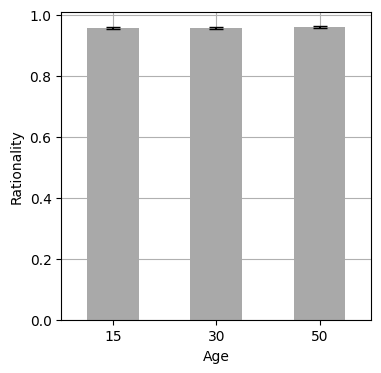

            sum_sq     df         F    PR(>F)
label     0.000287    1.0  0.500776  0.480085
Residual  0.101887  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0002 0.9983 -0.0101 0.0106  False
    15     50  -0.0029 0.7805 -0.0133 0.0074  False
    30     50  -0.0032 0.7484 -0.0135 0.0072  False
---------------------------------------------------
means:
age
15    0.0449
30    0.0452
50    0.0420
Name: explain_no_explanations, dtype: float64
stds:
age
15    0.0262
30    0.0210
50    0.0244
Name: explain_no_explanations, dtype: float64
age
15    60
30    60
50    60
Name: explain_no_explanations, dtype: int64


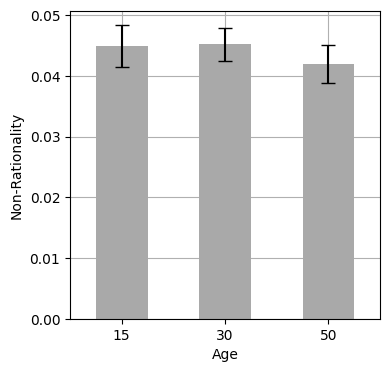

In [29]:
show_model_details(df, 'explain_', 'age')

            sum_sq     df         F    PR(>F)
label     0.000485    2.0  0.422347  0.656165
Residual  0.101688  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low  -0.0014 0.9475 -0.0117  0.009  False
  high medium   -0.004  0.638 -0.0143 0.0064  False
   low medium  -0.0026 0.8246 -0.0129 0.0078  False
---------------------------------------------------
means:
risk_taking
low       0.9564
medium    0.9538
high      0.9577
Name: explain_explanations, dtype: float64
stds:
risk_taking
low       0.0265
medium    0.0213
high      0.0238
Name: explain_explanations, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: explain_explanations, dtype: int64


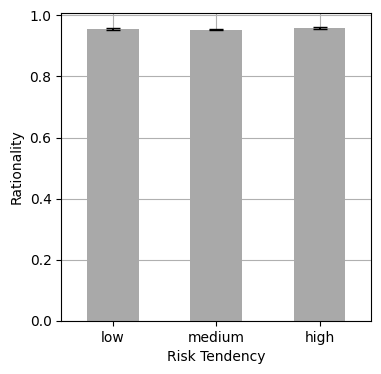

            sum_sq     df         F    PR(>F)
label     0.000485    2.0  0.422347  0.656166
Residual  0.101688  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low   0.0014 0.9475  -0.009 0.0117  False
  high medium    0.004  0.638 -0.0064 0.0143  False
   low medium   0.0026 0.8246 -0.0078 0.0129  False
---------------------------------------------------
means:
risk_taking
low       0.0436
medium    0.0462
high      0.0423
Name: explain_no_explanations, dtype: float64
stds:
risk_taking
low       0.0265
medium    0.0213
high      0.0238
Name: explain_no_explanations, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: explain_no_explanations, dtype: int64


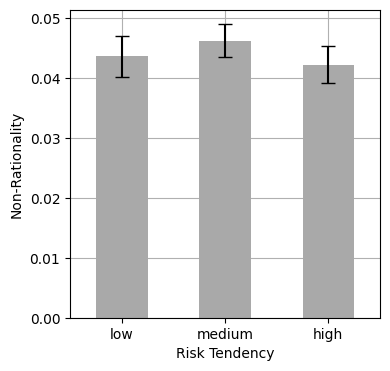

In [30]:
show_model_details(df, 'explain_', 'risk_taking')

### Assertiveness

In [31]:
show_colmeans(df, 'assertive_')

mean for column Assertiveness: 0.606 with length: 180
mean for column Non-Assertiveness: 0.394 with length: 180


            sum_sq     df         F    PR(>F)
label     0.094319    1.0  6.505001  0.011599
Residual  2.580909  178.0       NaN       NaN
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Control prompt Debiased prompt  -0.0458 0.0116 -0.0812 -0.0104   True
---------------------------------------------------------------------
means:
cond
Control prompt     0.6289
Debiased prompt    0.5831
Name: assertive_assertive, dtype: float64
stds:
cond
Control prompt     0.1240
Debiased prompt    0.1167
Name: assertive_assertive, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: assertive_assertive, dtype: int64


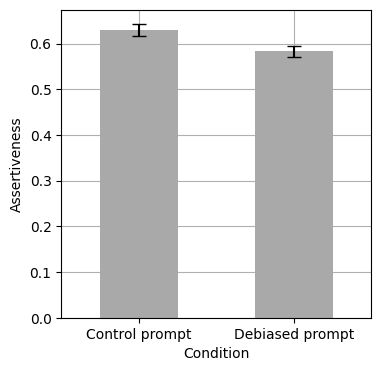

            sum_sq     df         F    PR(>F)
label     0.094319    1.0  6.505001  0.011599
Residual  2.580909  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1          group2     meandiff p-adj  lower  upper  reject
-------------------------------------------------------------------
Control prompt Debiased prompt   0.0458 0.0116 0.0104 0.0812   True
-------------------------------------------------------------------
means:
cond
Control prompt     0.3711
Debiased prompt    0.4169
Name: assertive_non_assertive, dtype: float64
stds:
cond
Control prompt     0.1240
Debiased prompt    0.1167
Name: assertive_non_assertive, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: assertive_non_assertive, dtype: int64


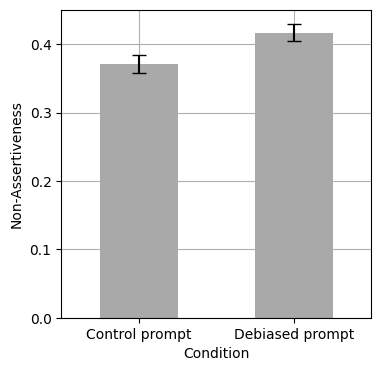

In [32]:
show_model_details(df, 'assertive_', 'cond')

            sum_sq     df         F    PR(>F)
label     0.003131    1.0  0.208548  0.648464
Residual  2.672098  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0075 0.9409 -0.0605 0.0456  False
    15     50  -0.0105 0.8871 -0.0635 0.0426  False
    30     50   -0.003 0.9902  -0.056   0.05  False
---------------------------------------------------
means:
age
15    0.6120
30    0.6045
50    0.6015
Name: assertive_assertive, dtype: float64
stds:
age
15    0.1198
30    0.1194
50    0.1292
Name: assertive_assertive, dtype: float64
age
15    60
30    60
50    60
Name: assertive_assertive, dtype: int64


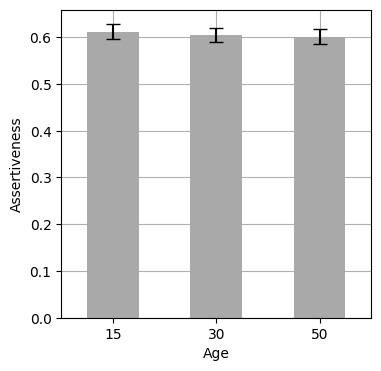

            sum_sq     df         F    PR(>F)
label     0.003131    1.0  0.208548  0.648464
Residual  2.672097  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0075 0.9409 -0.0456 0.0605  False
    15     50   0.0105 0.8871 -0.0426 0.0635  False
    30     50    0.003 0.9902   -0.05  0.056  False
---------------------------------------------------
means:
age
15    0.3880
30    0.3955
50    0.3985
Name: assertive_non_assertive, dtype: float64
stds:
age
15    0.1198
30    0.1194
50    0.1292
Name: assertive_non_assertive, dtype: float64
age
15    60
30    60
50    60
Name: assertive_non_assertive, dtype: int64


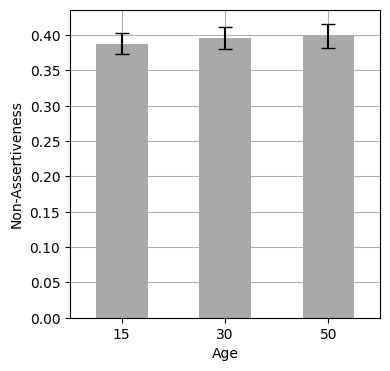

In [33]:
show_model_details(df, 'assertive_', 'age')

            sum_sq     df          F    PR(>F)
label     0.282133    2.0  10.433674  0.000052
Residual  2.393095  177.0        NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -0.0897 0.0001 -0.1399 -0.0395   True
  high medium  -0.0768 0.0011 -0.1269 -0.0266   True
   low medium   0.0129 0.8154 -0.0372  0.0631  False
----------------------------------------------------
means:
risk_taking
low       0.5718
medium    0.5847
high      0.6615
Name: assertive_assertive, dtype: float64
stds:
risk_taking
low       0.1100
medium    0.1200
high      0.1185
Name: assertive_assertive, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: assertive_assertive, dtype: int64


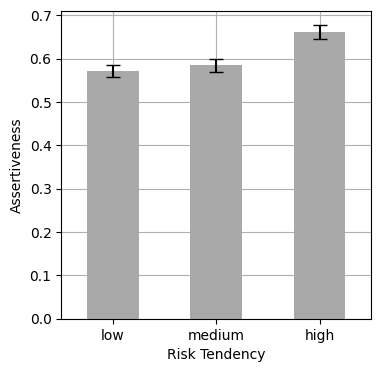

            sum_sq     df          F    PR(>F)
label     0.282133    2.0  10.433672  0.000052
Residual  2.393095  177.0        NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low   0.0897 0.0001  0.0395 0.1399   True
  high medium   0.0768 0.0011  0.0266 0.1269   True
   low medium  -0.0129 0.8154 -0.0631 0.0372  False
---------------------------------------------------
means:
risk_taking
low       0.4282
medium    0.4153
high      0.3385
Name: assertive_non_assertive, dtype: float64
stds:
risk_taking
low       0.1100
medium    0.1200
high      0.1185
Name: assertive_non_assertive, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: assertive_non_assertive, dtype: int64


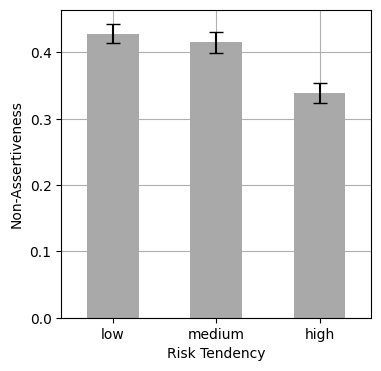

In [34]:
show_model_details(df, 'assertive_', 'risk_taking')

            sum_sq     df         F    PR(>F)
label     0.386963    5.0  5.884951  0.000047
Residual  2.288265  174.0       NaN       NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -0.1035 0.0078 -0.1888 -0.0181   True
  (Control prompt, high)  (Control prompt, medium)  -0.0946 0.0202   -0.18 -0.0093   True
  (Control prompt, high)   (Debiased prompt, high)  -0.0669  0.217 -0.1522  0.0185  False
  (Control prompt, high)    (Debiased prompt, low)  -0.1428    0.0 -0.2281 -0.0575   True
  (Control prompt, high) (Debiased prompt, medium)  -0.1258 0.0005 -0.2111 -0.0405   True
   (Control prompt, low)  (Control prompt, medium)   0.0088 0.9997 -0.0765  0.0942  False
   (Control prompt, low)   (Debiased prompt, high)  

<Figure size 640x480 with 0 Axes>

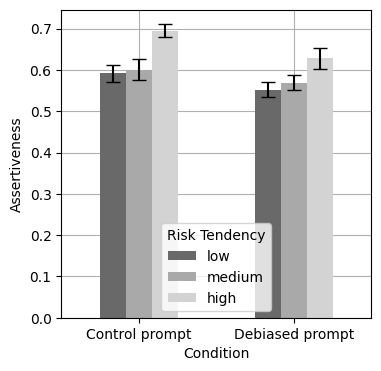

            sum_sq     df        F    PR(>F)
label     0.386963    5.0  5.88495  0.000047
Residual  2.288265  174.0      NaN       NaN
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower  upper  reject
----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)   0.1035 0.0078  0.0181 0.1888   True
  (Control prompt, high)  (Control prompt, medium)   0.0946 0.0202  0.0093   0.18   True
  (Control prompt, high)   (Debiased prompt, high)   0.0669  0.217 -0.0185 0.1522  False
  (Control prompt, high)    (Debiased prompt, low)   0.1428    0.0  0.0575 0.2281   True
  (Control prompt, high) (Debiased prompt, medium)   0.1258 0.0005  0.0405 0.2111   True
   (Control prompt, low)  (Control prompt, medium)  -0.0088 0.9997 -0.0942 0.0765  False
   (Control prompt, low)   (Debiased prompt, high)  -0.0366 0.81

<Figure size 640x480 with 0 Axes>

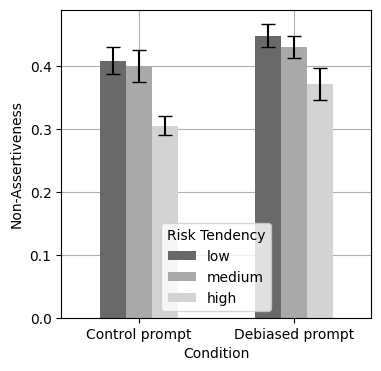

In [35]:
show_model_details(df, 'assertive_', 'cond', 'risk_taking')